In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Размер:", df.shape)
df.head()

Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [5]:
# Пытаемся превратить в число; что не сможет — станет NaN
tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Не распарсилось:", tc_numeric.isna().sum())
df[tc_numeric.isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Не распарсилось: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [6]:
# Превращаем в число (пробелы станут NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Заполняем пропуски нулём (это новые клиенты, tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Проверяем
print("Тип теперь:", df['TotalCharges'].dtype)
print("Пропусков осталось:", df['TotalCharges'].isna().sum())

Тип теперь: float64
Пропусков осталось: 0


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


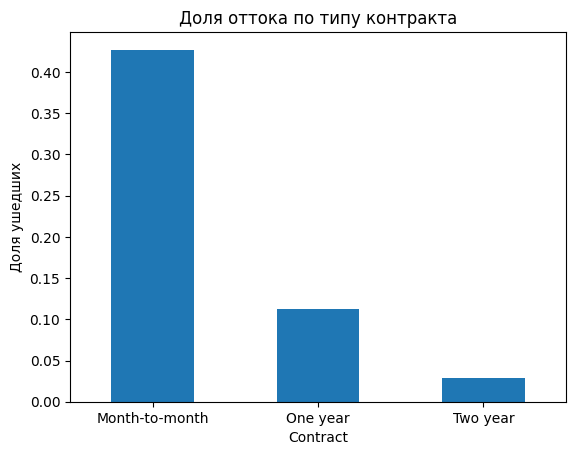

In [7]:
import matplotlib.pyplot as plt

# Доля ушедших внутри каждого типа контракта
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())
print(churn_by_contract)

# График
churn_by_contract.plot(kind='bar', title='Доля оттока по типу контракта')
plt.ylabel('Доля ушедших')
plt.xticks(rotation=0)
plt.show()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64



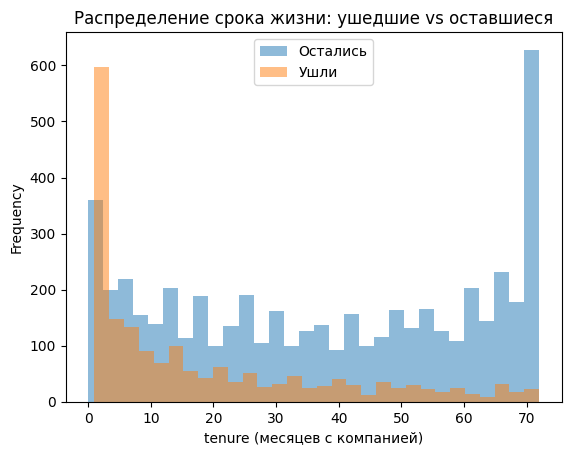

In [8]:
# Средний tenure у ушедших и оставшихся
print(df.groupby('Churn')['tenure'].mean())
print()

# Распределения — две гистограммы
df[df['Churn']=='No']['tenure'].plot(kind='hist', bins=30, alpha=0.5, label='Остались', legend=True)
df[df['Churn']=='Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.5, label='Ушли', legend=True)
plt.xlabel('tenure (месяцев с компанией)')
plt.title('Распределение срока жизни: ушедшие vs оставшиеся')
plt.show()

In [9]:
# 1. Таргет: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 2. Убираем бесполезный для модели customerID (это просто идентификатор)
df_model = df.drop('customerID', axis=1)

# 3. One-hot для всех категориальных признаков
df_model = pd.get_dummies(df_model, drop_first=True)

print("Размер до:", df.shape)
print("Размер после one-hot:", df_model.shape)
df_model.head()

Размер до: (7043, 21)
Размер после one-hot: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# stratify=y — сохраняем пропорцию классов (26.5% / 73.5%) и в train, и в test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Доля ушедших в train:", y_train.mean().round(4))
print("Доля ушедших в test:", y_test.mean().round(4))

Train: (5634, 30) Test: (1409, 30)
Доля ушедших в train: 0.2654
Доля ушедших в test: 0.2654


In [13]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print("Accuracy baseline:", round(dummy_acc, 4))

Accuracy baseline: 0.7346


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy baseline:", round(dummy_acc, 4))
print("Accuracy RandomForest:   ", round(accuracy_score(y_test, y_pred), 4))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy baseline: 0.7346
Accuracy RandomForest:    0.785

Confusion matrix:
[[920 115]
 [188 186]]


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1:       ", round(f1_score(y_test, y_pred), 4))

Precision: 0.6179
Recall:    0.4973
F1:        0.5511


In [17]:
# Вероятности ухода (а не метки) для тестовых клиентов
y_proba = rf.predict_proba(X_test)[:, 1]

# Сравним два порога: стандартный 0.5 и пониженный 0.3
for threshold in [0.5, 0.3]:
    y_pred_t = (y_proba >= threshold).astype(int)
    print(f"--- Порог {threshold} ---")
    print("Recall:   ", round(recall_score(y_test, y_pred_t), 4))
    print("Precision:", round(precision_score(y_test, y_pred_t), 4))
    print()

--- Порог 0.5 ---
Recall:    0.508
Precision: 0.6149

--- Порог 0.3 ---
Recall:    0.746
Precision: 0.5225



In [18]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.8253
